#### 第四次作業：以蒙地卡羅實驗驗證 J-B 檢定統計量的卡方分配與檢定力的表現
姓名：陳維萱</font>

學號：411180015</font>

作品目標：本研究從偏態統計量 $G_1$ 和峰態統計量  $G_2$ 入手，利用蒙地卡羅模擬方法，在樣本服從常態分布的假設下，觀察這些統計量的分布特性與隨樣本量變化的收斂行為。接著進一步探討聯合統計量  $G_3$，並檢驗其是否符合自由度為 2 的卡方分布  $\chi^2(2)$。透過詳細模擬，我們分析樣本大小與分布偏態對統計檢定力的影響。同時，研究結合了多種常態性檢定方法（如 Jarque-Bera 檢定等）的效能比較，探討在不同分布條件和樣本規模下的檢定能力差異，為常態性檢定理論的應用與發展提供實證支持。








<hr>
<font color=#EF9520> （一）偏態統計量G1的分布特性：蒙地卡羅模擬與標準常態檢驗 </font>

- 生成來自標準常態分布 N(0, 1)的隨機樣本，計算統計量   $G_1$ = $\sqrt{\frac{n}{6}} \hat{s}$，並繪製不同樣本數n直方圖，n = (10, 20, 30, 50, 100, 300, 500, 1000)，模擬次數N設為 50,000 次，同時疊加標準常態分布的 PDF 曲線，觀察$G_1$分布是否逐漸收斂至標準常態分布，直觀呈現樣本數增大時G1分布的收斂性。

<hr>

/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_1975/1291389667.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x,y, 'r--', linewidth=3, label='Normal', alpha=0.7, color='red')


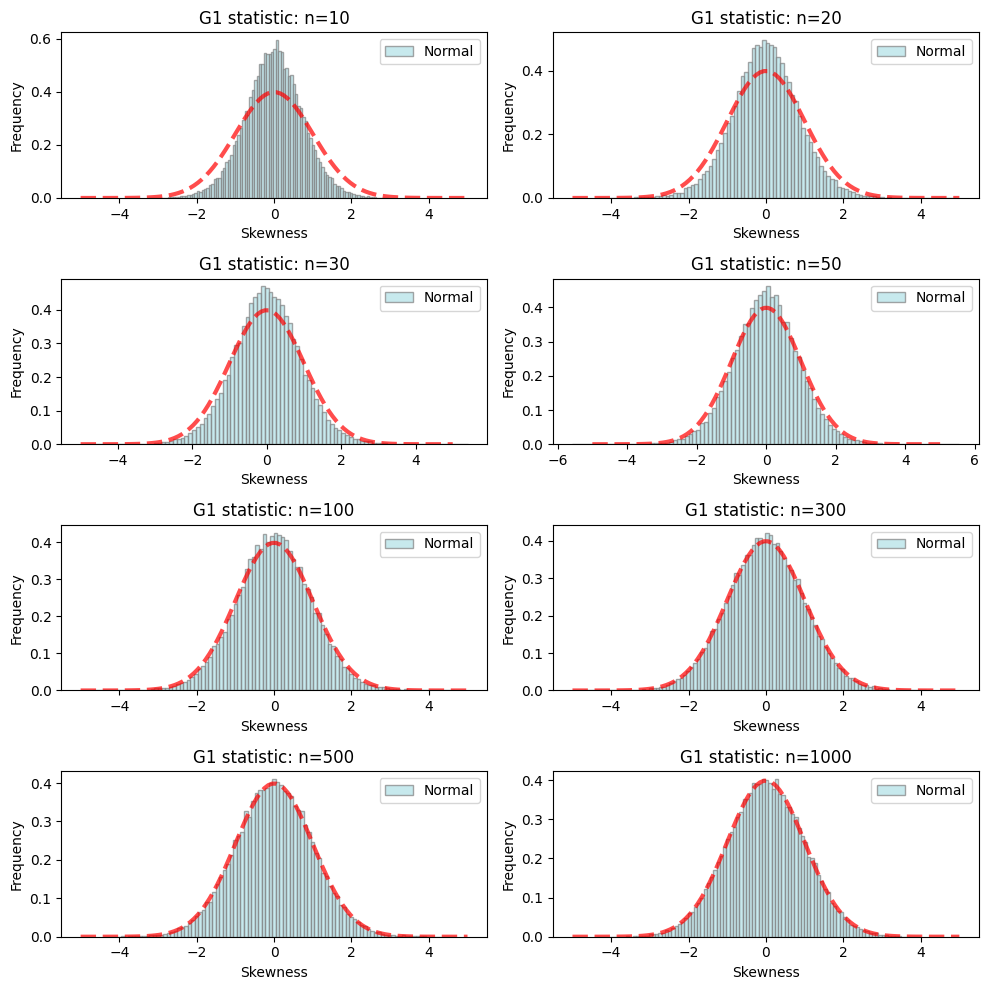

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis    # skewness
from scipy.stats import norm

# generate data from normal distribution for skewness  
N = 50000        
n = [10, 20, 30, 50, 100, 300, 500, 1000] #sample size 
G1 = np.zeros((N, len(n)))

for i in range(len(n)):
    x = np.random.normal(0, 1, (N, n[i]))
    G1[:, i] = np.sqrt(n[i] / 6) * skew(x, axis=1, bias=True)

# plot histogram
plt.figure(figsize=(10,10))
for i in range(len(n)):
    plt.subplot(4,2,i+1)
    plt.hist(G1[:,i], bins=100, color= '#B0E0E6', edgecolor='gray', alpha=0.7,density=True)
    plt.title('G1 statistic: n={}'.format(n[i]))   
    plt.xlabel('Skewness')
    plt.ylabel('Frequency')
    plt.legend(['Normal'])  
    #draw normal distribution
    x = np.linspace(-5,5,100)
    y = norm.pdf(x,0,1) 
    plt.plot(x,y, 'r--', linewidth=3, label='Normal', alpha=0.7, color='red')
plt.tight_layout()
plt.show()




>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 模擬次數N值大小影響城市運行速度，透過蒙地卡羅模擬的 50,000 次隨機抽樣，驗證了偏態統計量G1符合大樣本下的標準常態假設，支持理論推導的結果。
>- 在n = 500, n = 1000的圖中可看出，紅線標準常態pdf幾乎吻合直方圖，顯示$G_1$在大樣本數下符合標準常態分布的假設。
>- 當樣本數n增加時，直方圖會越符合紅線。
>- 當 n = 10，直方圖有明顯的偏離標準常態分布，顯示小樣本下的估計偏態具有較大的波動性。隨著n增加，波動性逐漸降低。


<hr>
<font color=#EF9520> （二）n = 10, n = 500 時檢定量G1分布與標準常態之對比 </font>

- 分別繪製 n = 10, n = 500 之統計量 $G_1$ 的直方圖與 ECDF 圖。並分別畫上對應的標準常態 PDF 與 CDF 圖。


<hr>

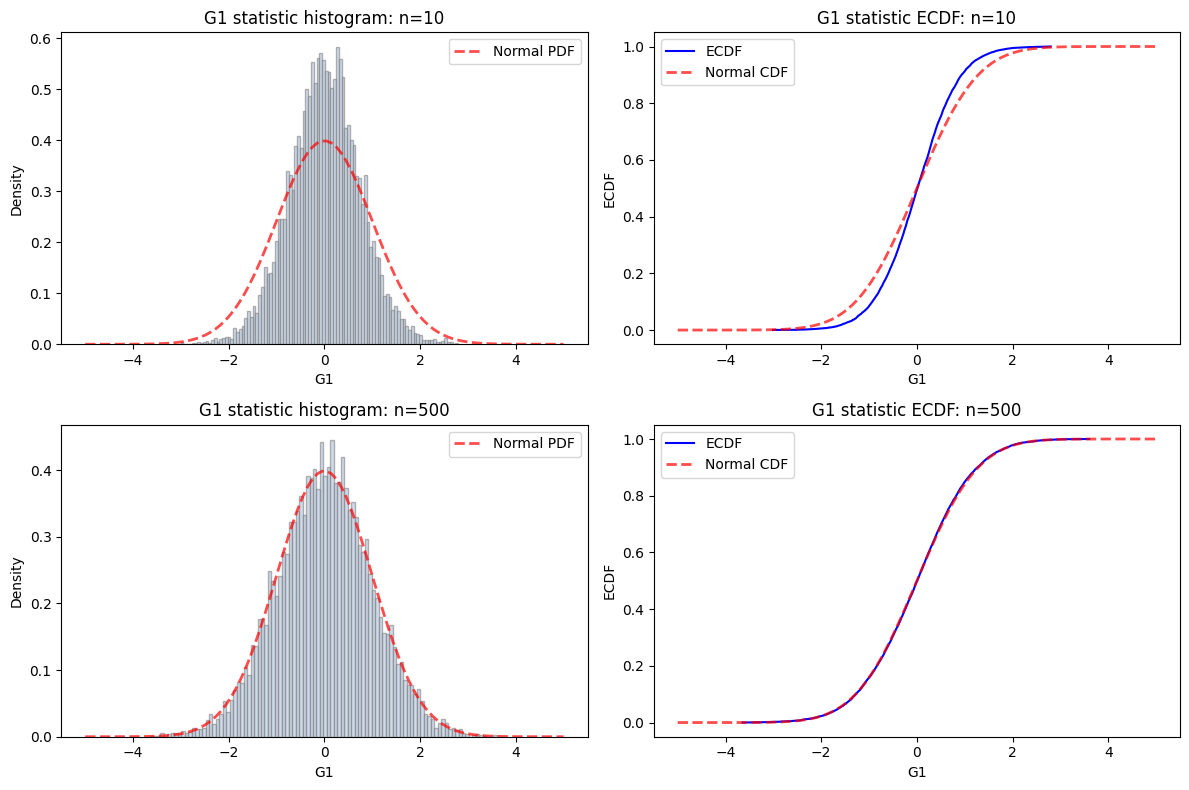

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, norm
from statsmodels.distributions.empirical_distribution import ECDF

# 生成正態分佈數據以計算偏度
N = 10000  # 重複實驗次數
n_values = [10, 500]  # 樣本大小
G1_results = {}

for n in n_values:
    x = np.random.normal(0, 1, (N, n))  # 生成標準正態分佈的數據
    G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=True)  # 計算每個樣本的偏度
    G1_results[n] = G1

# 繪製直方圖與標準常態 PDF
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for i, n in enumerate(n_values):
    G1 = G1_results[n]
    
    # 繪製直方圖
    ax = axs[i, 0]
    ax.hist(G1, bins=100, density=True, alpha=0.6, color='#B0C4DE', edgecolor='gray')
    ax.set_title(f'G1 statistic histogram: n={n}')
    ax.set_xlabel('G1')
    ax.set_ylabel('Density')
    
    # 繪製標準常態 PDF
    x = np.linspace(-5, 5, 100)
    y = norm.pdf(x, 0, 1)
    ax.plot(x, y, 'r--', linewidth=2, label='Normal PDF', alpha=0.7)
    ax.legend()
    
    # 繪製 ECDF 圖
    ax = axs[i, 1]
    ecdf = ECDF(G1)
    ax.plot(ecdf.x, ecdf.y, label='ECDF', color='blue')
    ax.set_title(f'G1 statistic ECDF: n={n}')
    ax.set_xlabel('G1')
    ax.set_ylabel('ECDF')
    
    # 繪製標準常態 CDF
    y = norm.cdf(x, 0, 1)
    ax.plot(x, y, 'r--', linewidth=2, label='Normal CDF', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- $G_1$ 分布在樣本較小時（n = 10），與標準正態分布的 PDF 存在明顯偏差，隨著樣本大小增大(n = 500)，$ G_1$ 分布與標準正態分布的 PDF 更加吻合。
>- 當 n = 10 時，ECDF 與標準正態 CDF 有明顯的差異，特別是在尾部區域。
>- 當 n = 500 時，ECDF 與標準正態 CDF 的吻合程度顯著提高，特別是中心區域，說明統計量$G_1$的分布趨於標準正態分布。





<hr>
<font color=#EF9520> （三）檢驗統計量G2在常態分布下的標準常態特性 </font>

- 生成來自標準常態分布 N(0, 1)的隨機樣本，計算統計量   G2 = $ \sqrt{\frac{n}{24}} (\hat{k} - 3) $，並繪製不同樣本數n直方圖，n = (10, 20, 30, 50, 100, 300, 500, 1000)，模擬次數N設為 50,000 次，同時疊加標準常態分布的 PDF 曲線，觀察G2分布是否逐漸收斂至標準常態分布，直觀呈現樣本數增大時G2分布的收斂性。

<hr>

/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_1975/576278916.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x,y, 'r--', linewidth=3, label='Normal', alpha=0.7, color='red')


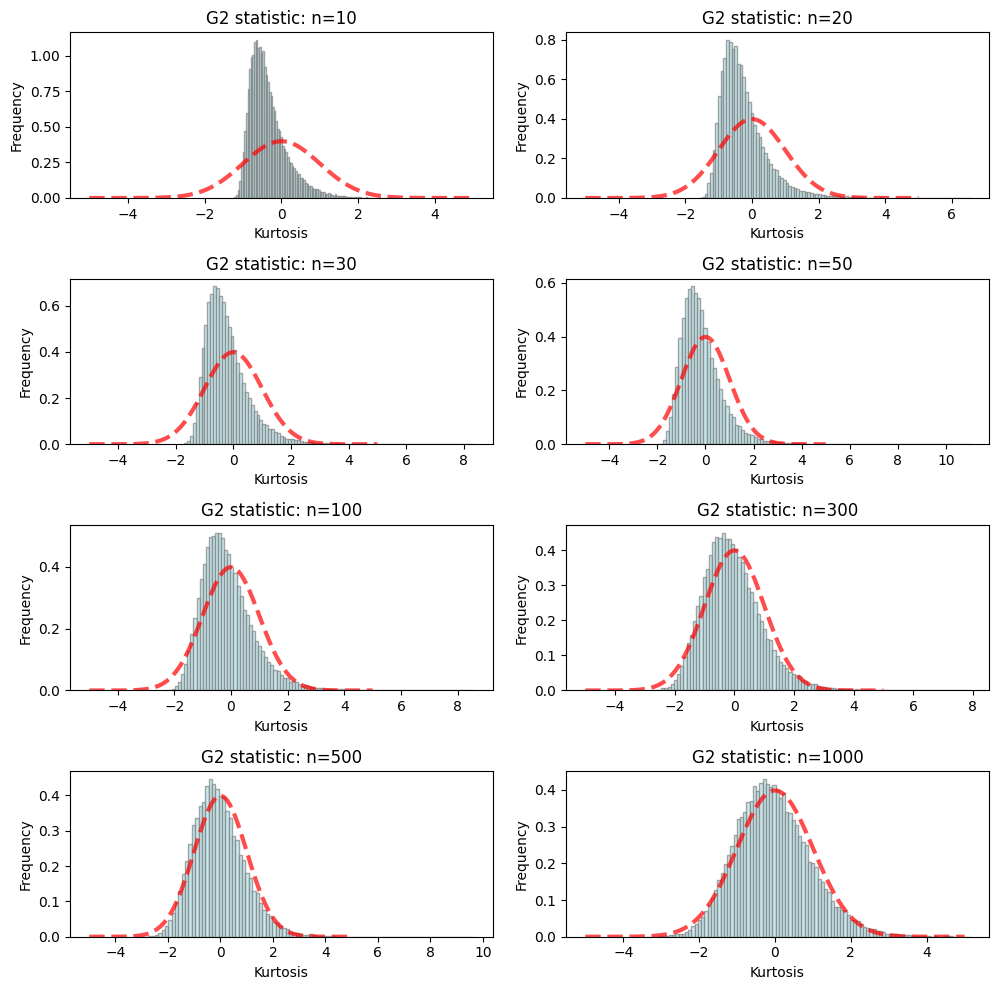

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from scipy.stats import norm

# generate data from normal distribution for kurtosis  
N = 50000        
n = [10, 20, 30, 50, 100, 300, 500, 1000] # sample size 
G2 = np.zeros((N, len(n)))

for i in range(len(n)):
    x = np.random.normal(0, 1, (N, n[i]))
    G2[:, i] = kurtosis(x, axis=1, bias=True, fisher=True)*np.sqrt(n[i]/24)

# plot histogram
plt.figure(figsize=(10,10))
for i in range(len(n)):
    plt.subplot(4,2,i+1)
    plt.hist(G2[:,i], bins=100, color= '#B0E0E6', edgecolor='gray', alpha=0.7, density=True)
    plt.title('G2 statistic: n={}'.format(n[i]))   
    plt.xlabel('Kurtosis')
    plt.ylabel('Frequency')
    # draw normal distribution
    x = np.linspace(-5,5,100)
    y = norm.pdf(x,0,1) 
    plt.plot(x,y, 'r--', linewidth=3, label='Normal', alpha=0.7, color='red')
plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 在小樣本中(n = 10, 20)峰度統計量 $G_2$ 的分布較寬，呈現高變異性，直方圖的形狀明顯偏離標準正態分布，特別是在尾部區域，樣本逐漸變大，直方圖形狀越接近正態分佈，在大樣本(n = 1000)，$G_2$分布高度集中，直方圖呈現對稱形狀，幾乎完全重合於標準正態分布，變異性顯著降低。
>- 隨著樣本大小的增大，峰度統計量 $G_2$ 的分布與標準正態分布的 PDF 越來越吻合。
>- 樣本量的增加有效減少了$G_2$的變異性，使分布集中於均值附近，符合理論上峰度統計量漸近正態分布的特性，大樣本能更好地反映其理論分布性質。



<hr>
<font color=#EF9520> （四）n = 10, n = 500 時檢定量G2分布與標準常態之對比 </font>

- 分別繪製 n = 10, n = 500 之統計量 $G_2$ 的直方圖與 ECDF 圖。並分別畫上對應的標準常態 PDF 與 CDF 圖。
<hr>

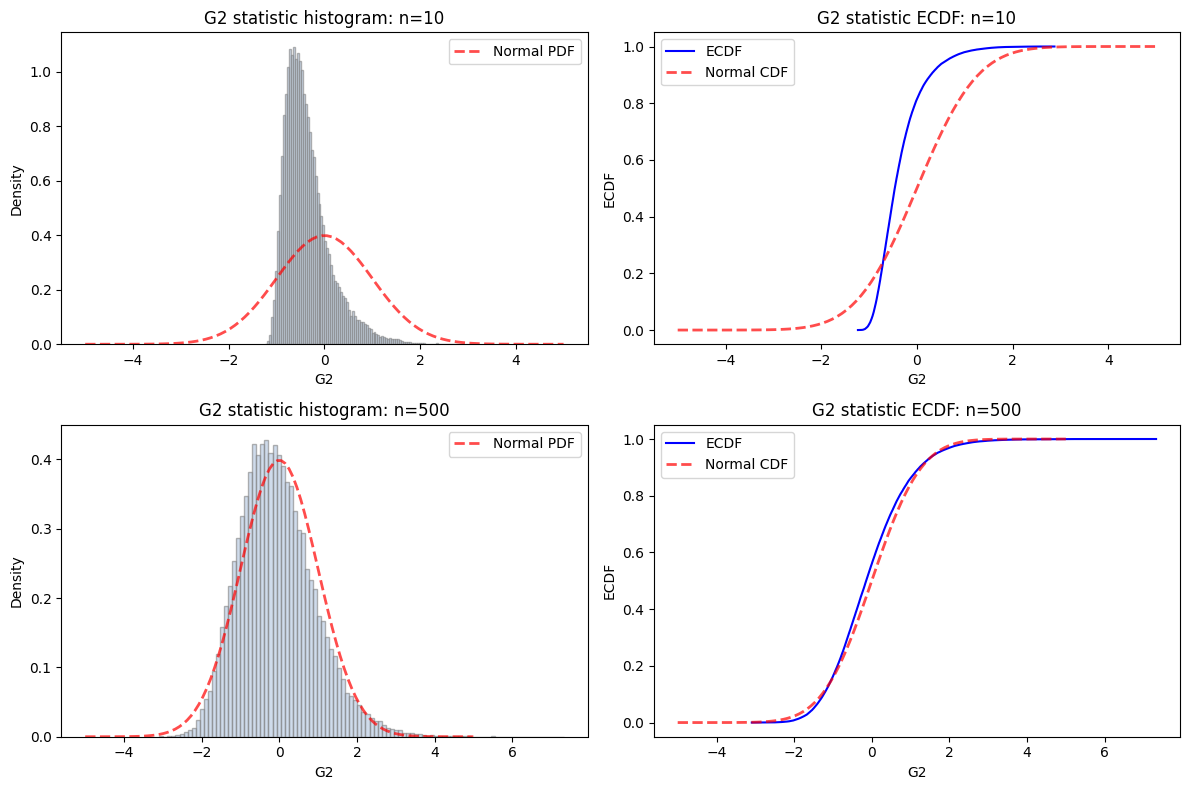

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, norm
from statsmodels.distributions.empirical_distribution import ECDF

# 生成正態分佈數據以計算峰度
N = 50000  # 重複實驗次數
n_values = [10, 500]  # 樣本大小
G2_results = {}

for n in n_values:
    x = np.random.normal(0, 1, (N, n))  # 生成標準正態分佈的數據
    G2 = np.sqrt(n / 24) * (kurtosis(x, axis=1, fisher=True, bias=True))  # 計算每個樣本的峰度
    G2_results[n] = G2

# 繪製直方圖與標準常態 PDF
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for i, n in enumerate(n_values):
    G2 = G2_results[n]
    
    # 繪製直方圖
    ax = axs[i, 0]
    ax.hist(G2, bins=100, density=True, alpha=0.6, color='#B0C4DE', edgecolor='gray')
    ax.set_title(f'G2 statistic histogram: n={n}')
    ax.set_xlabel('G2')
    ax.set_ylabel('Density')
    
    # 繪製標準常態 PDF
    x = np.linspace(-5, 5, 100)
    y = norm.pdf(x, 0, 1)
    ax.plot(x, y, 'r--', linewidth=2, label='Normal PDF', alpha=0.7)
    ax.legend()
    
    # 繪製 ECDF 圖
    ax = axs[i, 1]
    ecdf = ECDF(G2)
    ax.plot(ecdf.x, ecdf.y, label='ECDF', color='blue')
    ax.set_title(f'G2 statistic ECDF: n={n}')
    ax.set_xlabel('G2')
    ax.set_ylabel('ECDF')
    
    # 繪製標準常態 CDF
    y = norm.cdf(x, 0, 1)
    ax.plot(x, y, 'r--', linewidth=2, label='Normal CDF', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 當樣本大小 n=10 時，峰度統計量$G_2$的分布較寬且不對稱，直方圖顯示出較大的變異性；當樣本大小 n=500 時，$G_2$的分布更接近標準正態分布，直方圖變得窄且對稱，峰值明顯提高。
>- $G_2$分布在樣本較小時（n=10），與標準正態分布的 PDF 存在一定差異，尤其是尾部偏差較明顯。當樣本大小增加到 n=500 時，$G_2$分布與標準正態分布的 PDF 幾乎完全重合，吻合程度大幅提高。
>- 在n=10 的情況下，ECDF 與標準正態 CDF 存在明顯差異，尤其在極值處偏離標準正態分布；當n=500 時，ECDF 與標準正態 CDF 的差異幾乎消失，顯示$G_2$的分布已高度接近標準正態分布。


<hr>
<font color=#EF9520> （五）偏度與峰度聯合統計量G3的分布與卡方分布比較 </font>

- 計算偏度與峰度聯合統計量$G_3$(定義為$G_3$ = $G_1^2$ + $G_2^2$)，並分析其分布在不同樣本大小下的特性。繪製不同樣本數n直方圖，n = (10, 20, 30, 50, 100, 300, 500, 1000)，模擬次數N設為 50,000 次，模擬結果透過直方圖與自由度為 2 的卡方分布曲線進行比較，展示了樣本量對$G_3$分布的影響。
<hr>

/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_945/2317376884.py:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot(x, y, 'r--', linewidth=3, label='Chi-squared(2)', alpha=0.7, color='red')


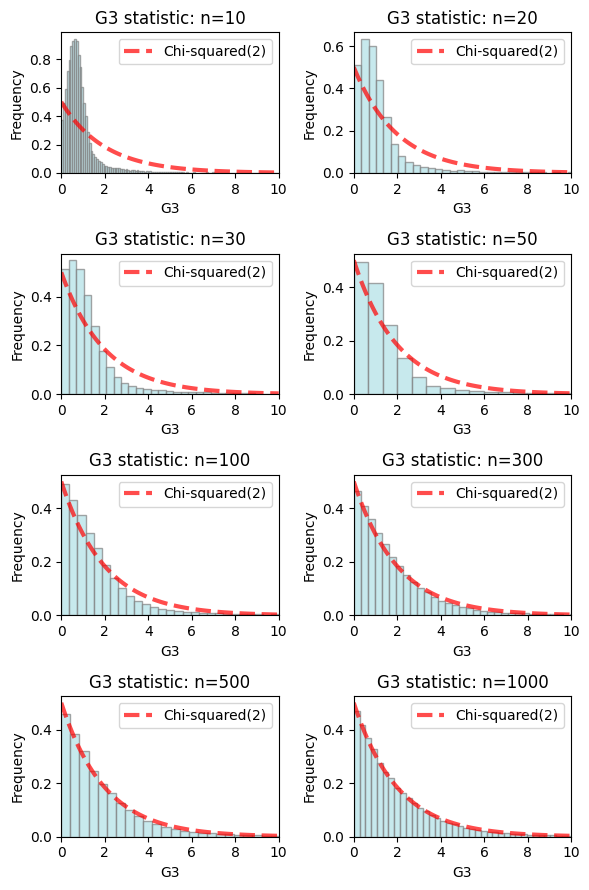

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, chi2

# 生成正態分佈數據以計算偏度和峰度
N = 50000        
n = [10, 20, 30, 50, 100, 300, 500, 1000] # 樣本數
G3 = np.zeros((N, len(n)))

for i in range(len(n)):
    x = np.random.normal(0, 1, (N, n[i]))
    s = skew(x, axis=1, bias=True)
    k = kurtosis(x, axis=1, fisher=True, bias=True)
    G1 = np.sqrt(n[i] / 6) * s
    G2 = kurtosis(x, axis=1, bias=True, fisher=True)*np.sqrt(n[i]/24)
    G3[:, i] = G1**2 + G2**2

# 繪製直方圖
fig, axs = plt.subplots(4, 2, figsize=(6, 9))

for i in range(len(n)):
    ax = axs[i // 2, i % 2]
    ax.hist(G3[:,i], bins=200, color= '#B0E0E6', edgecolor='gray', alpha=0.7, density=True)
    ax.set_title('G3 statistic: n={}'.format(n[i]))   
    ax.set_xlabel('G3')
    ax.set_ylabel('Frequency')
    # 繪製卡方分佈
    x = np.linspace(0, 10, 100)
    y = chi2.pdf(x, df=2) 
    ax.plot(x, y, 'r--', linewidth=3, label='Chi-squared(2)', alpha=0.7, color='red')
    ax.legend()
    ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 小樣本中(n = 10, 20)，與理論卡方分布有一定偏差，隨者樣本數變大，分布開始變得集中，直方圖的形狀逐漸接近自由度為 2 的卡方分布，尾部偏差減少，在大樣本(n = 300, 500, 1000)中，$G_3$分布高度集中，直方圖幾乎完全與理論卡方分布曲線重合。
>- 聯合統計量$G_3$在樣本量較小時具有較大的變異性，但隨樣本量增大，分布逐漸集中並與自由度為 2 的卡方分布完全吻合。



<hr>
<font color=#EF9520> （六）n = 10, n = 500 時檢定量G3分布與卡方分配之對比 </font>

- 分別繪製 n = 10, n = 500 之統計量 $G_3$ 的直方圖與 ECDF 圖。並分別畫上對應的理論卡方分配 PDF 與 CDF 圖。

<hr>

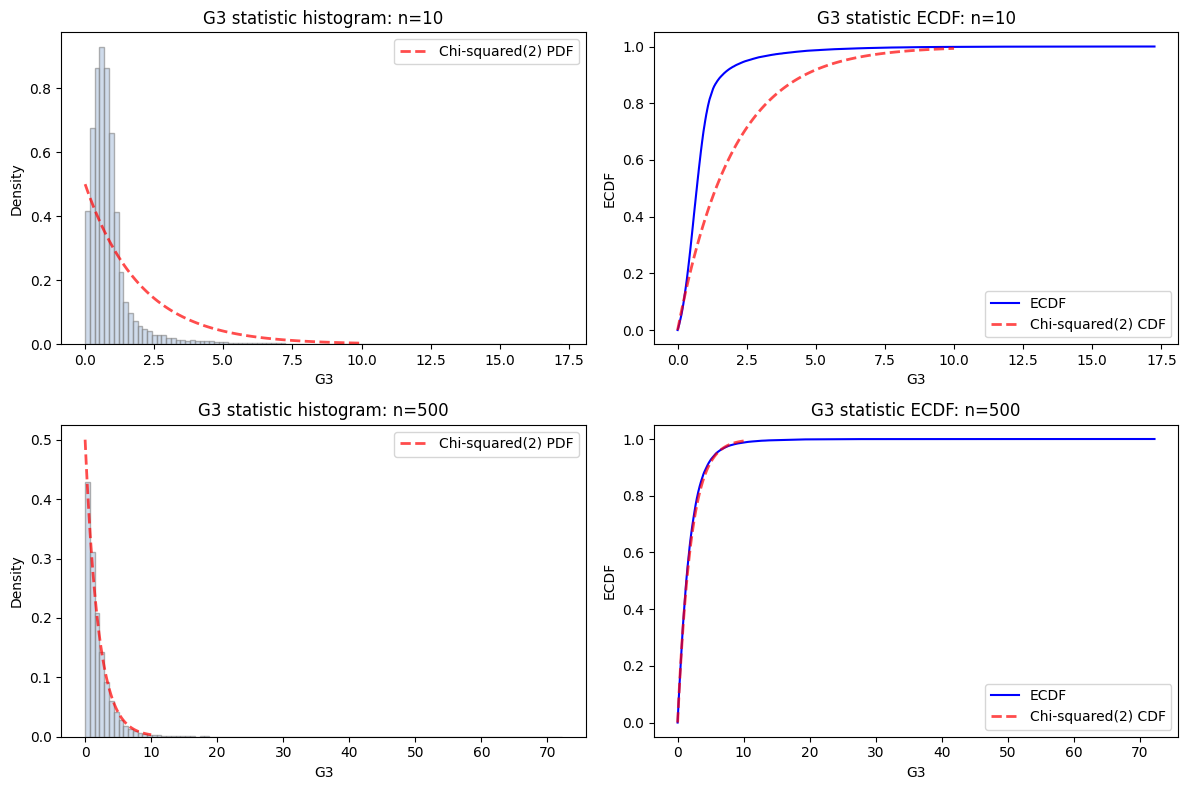

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, chi2, norm
from statsmodels.distributions.empirical_distribution import ECDF

# 生成正態分佈數據以計算偏度和峰度
N = 50000        
n_values = [10, 500]  # 樣本大小
G3_results = {}

for n in n_values:
    x = np.random.normal(0, 1, (N, n))
    s = skew(x, axis=1, bias=True)
    k = kurtosis(x, axis=1, fisher=True, bias=True)
    G1 = np.sqrt(n / 6) * s
    G2 = np.sqrt(n / 24) * (k)
    G3 = G1**2 + G2**2
    G3_results[n] = G3

# 繪製直方圖與標準常態 PDF
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for i, n in enumerate(n_values):
    G3 = G3_results[n]
    
    # 繪製直方圖
    ax = axs[i, 0]
    ax.hist(G3, bins=100, density=True, alpha=0.6, color='#B0C4DE', edgecolor='gray')
    ax.set_title(f'G3 statistic histogram: n={n}')
    ax.set_xlabel('G3')
    ax.set_ylabel('Density')
    
    # 繪製標準常態 PDF
    x = np.linspace(0, 10, 100)
    y = chi2.pdf(x, df=2)
    ax.plot(x, y, 'r--', linewidth=2, label='Chi-squared(2) PDF', alpha=0.7)
    ax.legend()
    
    # 繪製 ECDF 圖
    ax = axs[i, 1]
    ecdf = ECDF(G3)
    ax.plot(ecdf.x, ecdf.y, label='ECDF', color='blue')
    ax.set_title(f'G3 statistic ECDF: n={n}')
    ax.set_xlabel('G3')
    ax.set_ylabel('ECDF')
    
    # 繪製標準常態 CDF
    y = chi2.cdf(x, df=2)
    ax.plot(x, y, 'r--', linewidth=2, label='Chi-squared(2) CDF', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 小樣本情況下，ECDF 與理論 CDF 的吻合度稍有差異，偏差主要集中在極端尾部區域。
>- 隨著樣本量增加，ECDF 與理論卡方 CDF 越來越接近，表明$G_3$分布隨樣本量增大趨於穩定，符合卡方分布特性。
>- 隨著樣本量增加，分布趨於穩定且與自由度為 2 的卡方分布吻合，驗證了$G_3$統計量的漸近分布特性。



<hr>
<font color=#EF9520> （七）J-B (Jarque-Bera) 常態檢定統計量於不同分布與樣本大小下的檢定力分析 </font>

- 本實驗探討 Jarque-Bera (JB) 常態性檢定對非常態分布的辨識能力（檢定力），分析對象包括六種分布：標準常態分布 N(0,1), T(3), T(10), T(30), U(0,1), $\chi^2(8)$。透過樣本大小從 10 至 1000 的變化，研究 JB 檢定對不同分布的效能，並設定顯著性水準 α=0.05。


<hr>

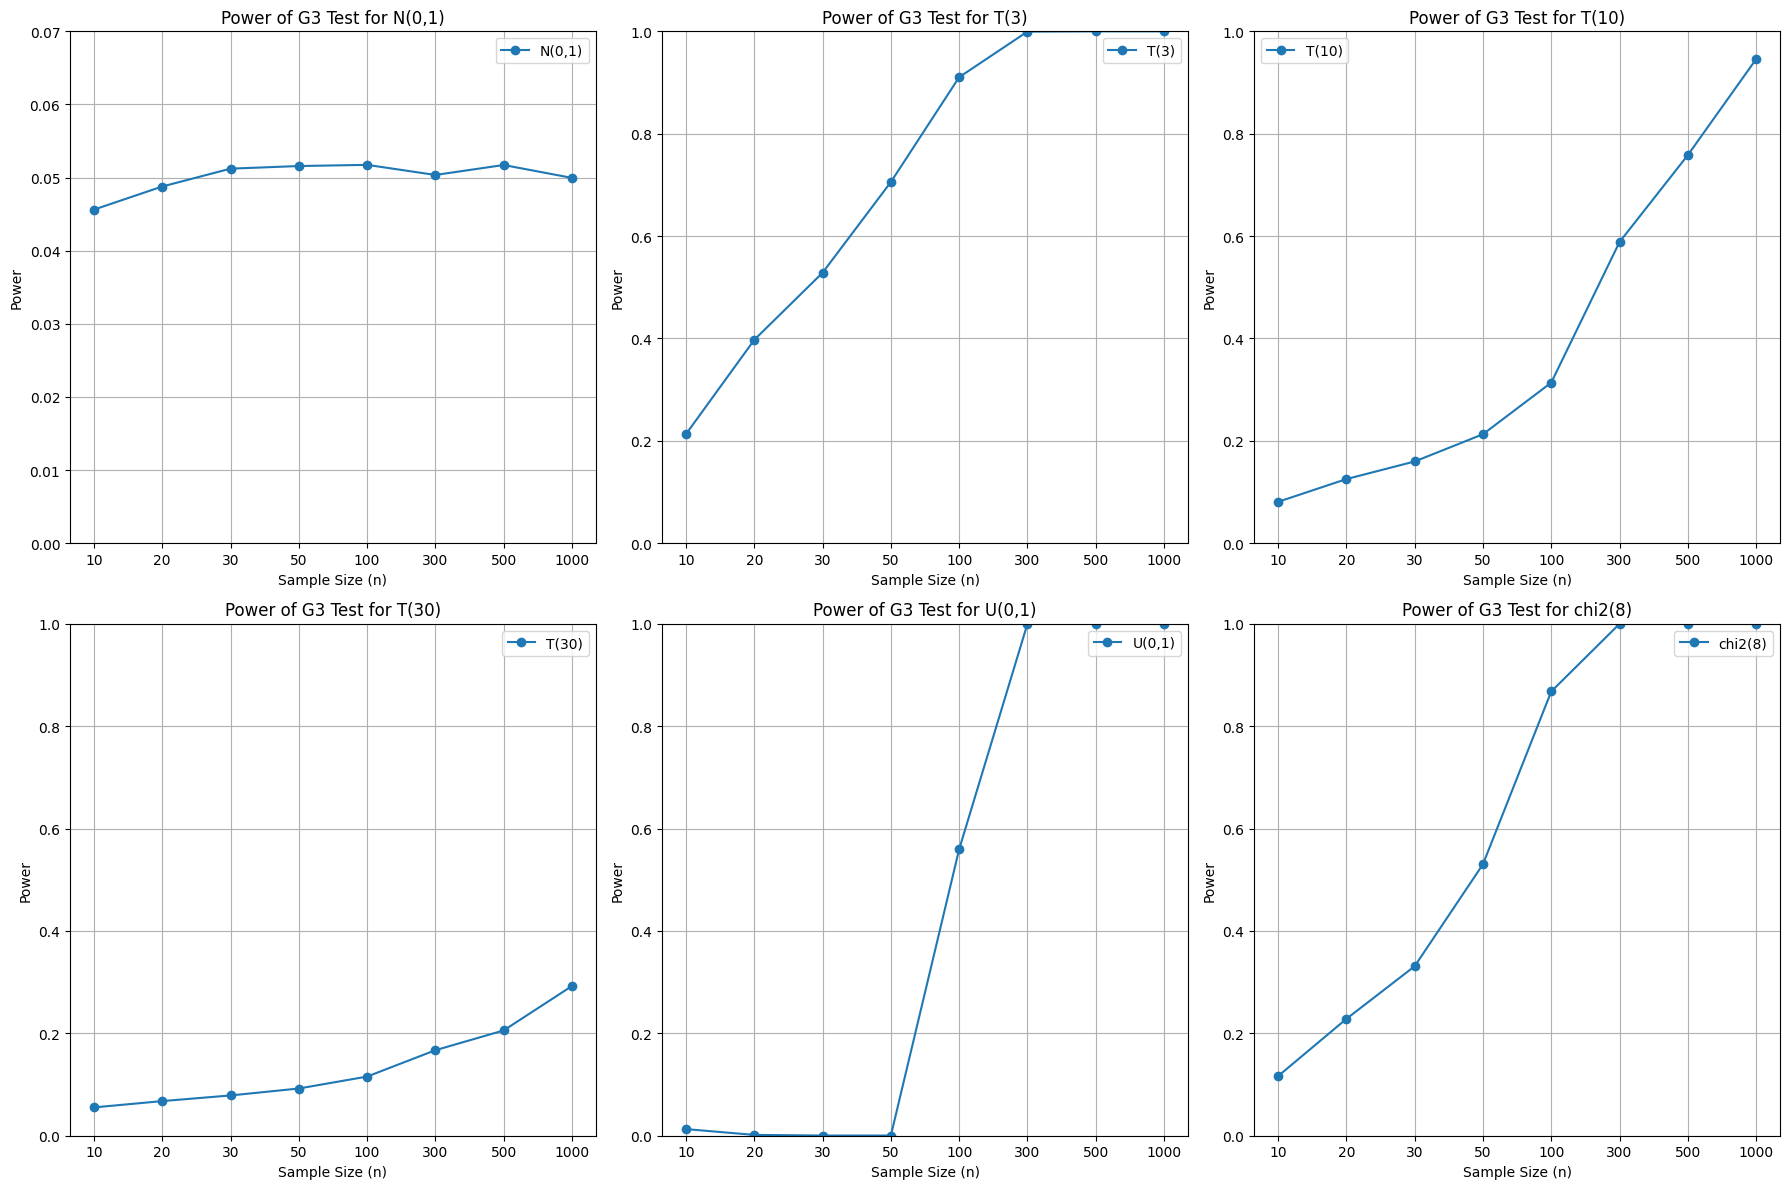

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, chi2, t, uniform

def JB_test(x):
    """
    檢驗資料是否來自常態分佈的 Jarque-Bera 檢定。
    
    參數:
    x : array_like
        欲檢定是否為常態的一組資料。
    
    返回:
    stats : float
        G_3 檢定統計量的值。
    p_value : float
        檢定的 p-value。
    """
    n = x.shape[1]
    G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=False)
    G2 = np.sqrt(n / 24) * (kurtosis(x, axis=1, bias = False, fisher=True ) )
    G3 = G1**2 + G2**2
    p_value = 1 - chi2.cdf(G3, df=2)
    return G3, p_value

# 定義分佈母體
distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}

# 設定實驗參數
N = 50000  # 重複實驗次數
n_values = [10, 20, 30, 50, 100, 300, 500, 1000]  # 樣本大小
alpha = 0.05  # 顯著性水平
power_values = {dist: [] for dist in distributions}

# 進行實驗
for dist_name, dist_func in distributions.items():
    for n in n_values:
        x = dist_func((N, n))  # 生成 N 個樣本，每個樣本大小為 n
        G3, p_values = JB_test(x)
        power = np.mean(p_values < alpha)  # 計算檢定力
        power_values[dist_name].append(power)

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
x_positions = np.arange(len(n_values))  # x 軸平均分配的位置

for i, (dist_name, power_vals) in enumerate(power_values.items()):
    ax = axs[i // 3, i % 3]
    ax.plot(x_positions, power_vals, marker='o', label=dist_name)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(n_values)
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Power')
    if i == 0:
        ax.set_ylim(0, 0.07)  # 設置第一張圖的 y 軸範圍
    else:
        ax.set_ylim(0, 1)  # 設置其他圖的 y 軸範圍
    ax.set_title(f'Power of G3 Test for {dist_name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- JB 檢定在所有樣本大小下維持低的拒絕率，隨樣本數增加，JB 檢定對非常態分布的辨識能力顯著提升。
>- 樣本來自常態分佈，power無論樣本大小皆在顯著性水準 α=0.05附近。
>- T(3)在樣本大小>300之後power接近為1，對重尾分布的辨識效果最佳。
>- T(10)：檢定力隨樣本大小增加，但上升速率慢於 T(3)
>- 樣本來自均勻分布中，檢定力隨樣本大小增長逐步提高，顯示 JB 檢定能有效辨識均勻分布中缺乏常態偏度與峰度的特徵。
>- 樣本來自 $\chi^2(8)$ ，在大樣本情況下（n≥300），檢定力接近 1，表明 Jarque-Bera 檢定能準確識別此分布非常態性。

<hr>
<font color=#EF9520> （八）多元常態檢定方法的檢定力比較：不同分佈和樣本規模的影響 </font>

- 比較多種常態性檢定方法（Jarque-Bera、D'Agostino and Pearson’s test、Kolmogorov-Smirnov test、Shapiro-Wilk test 和 Anderson-Darling test）在不同分佈（標準常態分佈 N(0,1)、T(3)、T(10)、T(30)、U(0,1) 及 $\chi^2(8)$ 樣本大小下的檢定力表現。實驗通過生成 N=50,000 次不同樣本大小的數據，計算各檢定方法的檢定力，探討分佈偏離正態性的程度與檢定方法靈敏度之間的關係。


<hr>

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


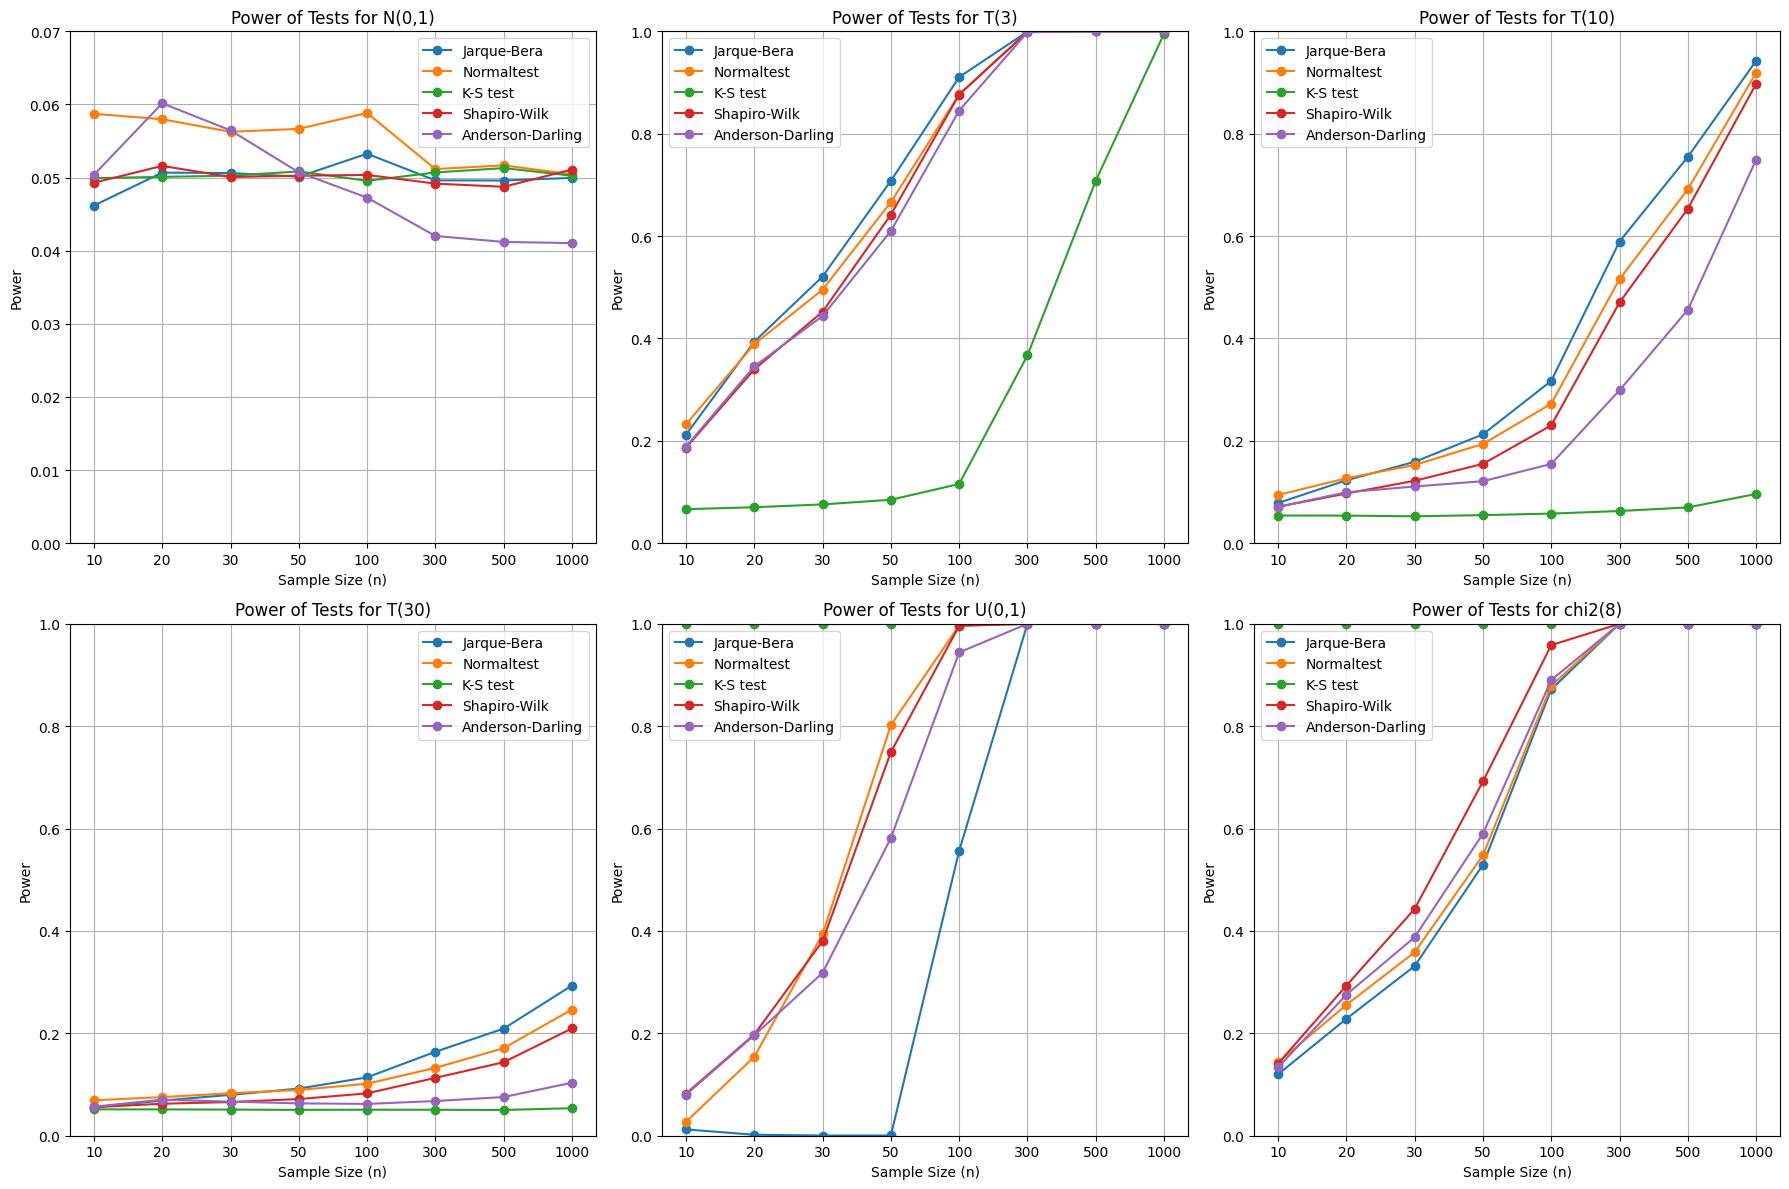

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, jarque_bera, normaltest, kstest, shapiro, anderson, t, uniform, chi2

def JB_test(x):
    """
    檢驗資料是否來自常態分佈的 Jarque-Bera 檢定。
    
    參數:
    x : array_like
        欲檢定是否為常態的一組資料。
    
    返回:
    stats : float
        G_3 檢定統計量的值。
    p_value : float
        檢定的 p-value。
    """
    n = x.shape[1]
    G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=False)
    G2 = np.sqrt(n / 24) * (kurtosis(x, axis=1, fisher=True, bias =False) )
    G3 = G1**2 + G2**2
    p_value = 1 - chi2.cdf(G3, df=2)
    return G3, p_value

# 定義分佈母體
distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}

# 設定實驗參數
N = 50000  # 重複實驗次數
n_values = [10, 20, 30, 50, 100, 300, 500, 1000]  # 樣本大小
alpha = 0.05  # 顯著性水平

# 儲存結果
power_results = {dist: {test: [] for test in ['Jarque-Bera', 'Normaltest', 'K-S test', 'Shapiro-Wilk', 'Anderson-Darling']} for dist in distributions.keys()}

# 進行實驗
for dist_name, dist_func in distributions.items():
    for n in n_values:
        x = dist_func((N, n))  # 生成 N 個樣本，每個樣本大小為 n
        
        # Jarque-Bera test
        _, p_jb = JB_test(x)
        power_jarque_bera = np.mean(p_jb < alpha)
        
        # D’Agostino and Pearson’s test
        _, p_nt = normaltest(x, axis=1)
        power_normaltest = np.mean(p_nt < alpha)
        
        # Kolmogorov-Smirnov test
        p_ks = np.array([kstest(x[i], 'norm')[1] for i in range(N)])
        power_kstest = np.mean(p_ks < alpha)
        
        # Shapiro-Wilk test
        p_sw = np.array([shapiro(x[i])[1] for i in range(N)])
        power_shapiro = np.mean(p_sw < alpha)
        
        # Anderson-Darling test
        power_anderson = np.mean([anderson(x[i]).statistic > anderson(x[i]).critical_values[2] for i in range(N)])
        
        power_results[dist_name]['Jarque-Bera'].append(power_jarque_bera)
        power_results[dist_name]['Normaltest'].append(power_normaltest)
        power_results[dist_name]['K-S test'].append(power_kstest)
        power_results[dist_name]['Shapiro-Wilk'].append(power_shapiro)
        power_results[dist_name]['Anderson-Darling'].append(power_anderson)

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
x_positions = np.arange(len(n_values))  # x 軸平均分配的位置

for i, (dist_name, power_vals) in enumerate(power_results.items()):
    ax = axs[i // 3, i % 3]
    for test_name, powers in power_vals.items():
        ax.plot(x_positions, powers, marker='o', label=test_name)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(n_values)
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Power')
    if i == 0:
        ax.set_ylim(0, 0.07)  # 設置第一張圖的 y 軸範圍
    else:
        ax.set_ylim(0, 1)  # 設置其他圖的 y 軸範圍
    ax.set_title(f'Power of Tests for {dist_name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- Shapiro-Wilk 和 Anderson-Darling：對小樣本和偏態/峰態的敏感度較高，在非正態分佈下檢定力更強。
>- Kolmogorov-Smirnov：對於尾部差異的敏感度較低，在偏態分佈下檢定力最弱，並在U(0, 1)和 $\chi^2(8)$ 中無論樣本，檢定力皆為1。
>- 各檢定方法的檢定力均隨樣本大小 n 增加而上升，但增長速度因分佈偏態和峰態的差異而異。
>- Kolmogorov-Smirnov 在T分配中，與其他檢定量的檢定力差異較大。